# EconoScope - Global Inflation & Economic Analysis

**Dataset:** Global Inflation Dataset (212 countries, 1970-2022)  
**Source:** [Kaggle - Global Inflation Dataset](https://www.kaggle.com/datasets/belayethossainds/global-inflation-dataset-212-country-19702022)  
**Goal:** Analyse global inflation trends, country comparisons, inflation types and historical spikes.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

matplotlib.rcParams['font.family']        = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 12

OUT = 'outputs'
print('Libraries loaded!')

Libraries loaded!


## 2. Load & Prepare Data

In [2]:
raw = pd.read_csv('data/Global Dataset of Inflation.csv', encoding='latin-1')

# Year columns
year_cols = [c for c in raw.columns if c.isdigit()]

# Focus on Headline CPI
headline = raw[raw['Series Name'] == 'Headline Consumer Price Inflation'].copy()
headline = headline[['Country', 'Country Code'] + year_cols].set_index(['Country', 'Country Code'])
headline = headline.apply(pd.to_numeric, errors='coerce')

# Drop mostly-empty columns
headline = headline.dropna(axis=1, thresh=50)
year_cols = [c for c in headline.columns]

print(f'Countries : {len(headline)}')
print(f'Years     : {year_cols[0]} - {year_cols[-1]}')
headline.head()

Countries : 203
Years     : 1970 - 2022


,,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Country,Country Code,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.37,0.42,0.48,-0.89,-0.47,3.58,4.26,1.22,0.74,6.04
Afghanistan,AFG,25.51,25.51,-12.52,-10.68,10.23,11.85,0.60,7.65,5.00,9.90,...,7.39,4.67,-0.66,4.38,4.98,0.63,2.30,5.44,5.06,NaN
Angola,AGO,7.97,5.78,15.80,15.67,27.42,29.00,80.70,69.01,48.46,101.30,...,8.78,7.30,9.16,32.38,29.84,19.63,17.08,21.02,23.85,21.35
Albania,ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.93,1.62,1.91,1.29,1.99,2.03,1.41,1.62,2.04,6.73
United Arab Emirates,ARE,21.98,21.98,21.98,21.98,21.98,21.98,21.98,21.97,13.04,10.99,...,1.09,2.34,4.07,1.62,1.97,3.06,-1.93,-2.08,0.18,5.22


In [ ]:
countries = ['United States', 'Germany', 'South Africa', 'Brazil', 'Japan', 'China']
colors    = ['#3b82f6', '#f59e0b', '#ef4444', '#10b981', '#8b5cf6', '#f97316']

sel = headline.reset_index()
sel = sel[sel['Country'].isin(countries)].set_index('Country')

fig, ax = plt.subplots(figsize=(14, 6))
for country, color in zip(countries, colors):
    if country in sel.index:
        data = sel.loc[country].drop('Country Code', errors='ignore').dropna()
        ax.plot(data.index.astype(int), data.values, label=country, color=color, linewidth=2)

ax.set_title('Inflation Rate - Major Economies (1970-2022)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT}/country_comparison.png', dpi=150)
plt.show()

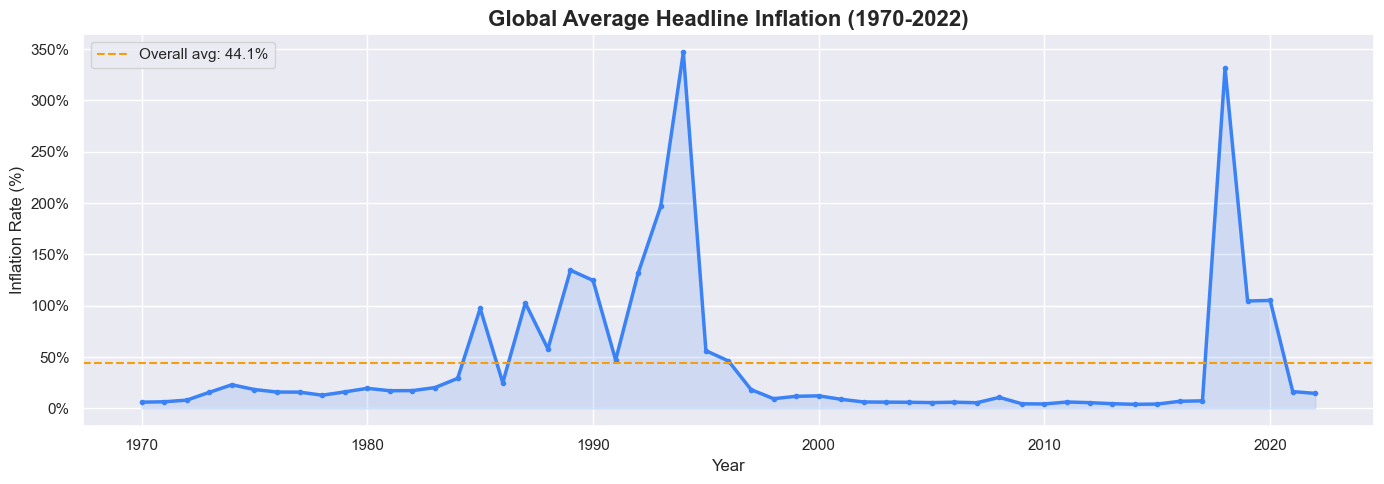

In [4]:
global_avg = headline.mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(global_avg.index.astype(int), global_avg.values, color='#3b82f6', linewidth=2.5, marker='o', markersize=3)
ax.fill_between(global_avg.index.astype(int), global_avg.values, alpha=0.15, color='#3b82f6')
ax.axhline(global_avg.mean(), color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Overall avg: {global_avg.mean():.1f}%')
ax.set_title('Global Average Headline Inflation (1970-2022)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/global_inflation_trend.png', dpi=150)
plt.show()

## 4. Country Comparison - Major Economies

In [ ]:
focus = ['United States', 'Germany', 'Argentina', 'Brazil', 'Japan',
         'China', 'United Kingdom', 'India', 'Russia', 'South Africa']

sel2 = headline.reset_index()
sel2 = sel2[sel2['Country'].isin(focus)].set_index('Country').drop('Country Code', axis=1)

decades = {}
for start in range(1970, 2020, 10):
    cols = [str(y) for y in range(start, start+10) if str(y) in sel2.columns]
    if cols:
        decades[f'{start}s'] = sel2[cols].mean(axis=1)
cols_2020 = [c for c in ['2020','2021','2022'] if c in sel2.columns]
if cols_2020:
    decades['2020-22'] = sel2[cols_2020].mean(axis=1)

heat = pd.DataFrame(decades).clip(upper=100)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Avg Inflation by Decade - Selected Countries (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{OUT}/inflation_heatmap.png', dpi=150)
plt.show()

## 5. Top 15 Highest Inflation Countries (2022)

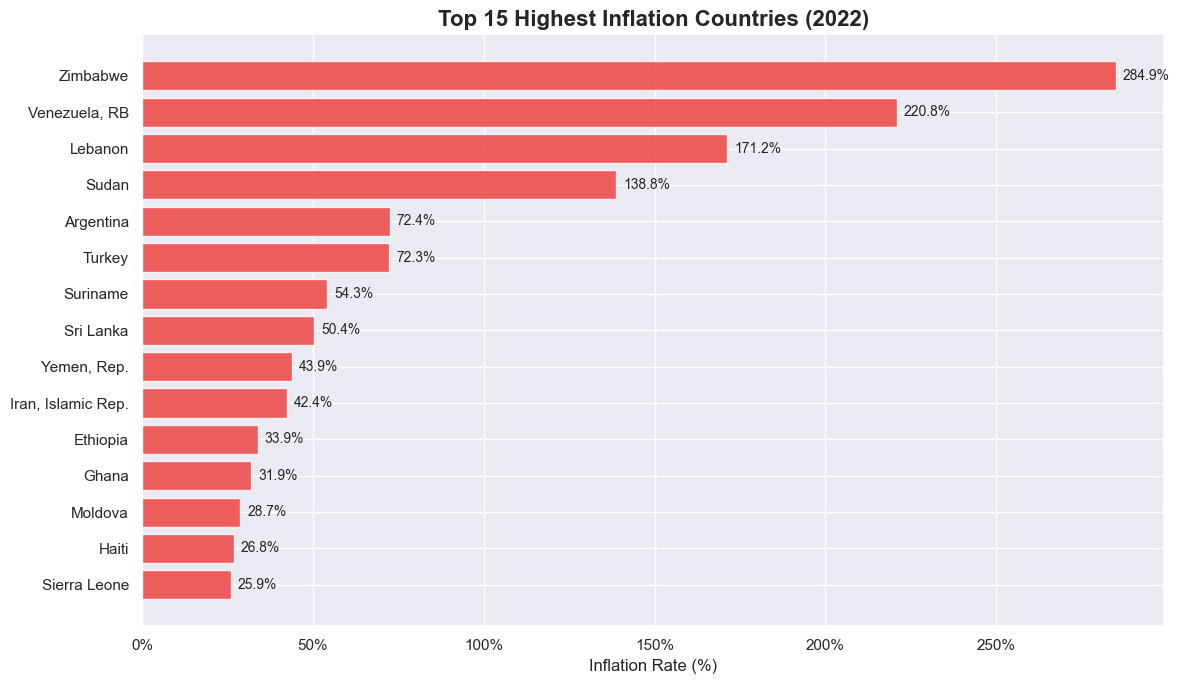

In [6]:
last_year = year_cols[-1]
top15 = (
    headline[last_year]
    .dropna()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top15.columns = ['Country', 'Code', 'Inflation']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['Country'], top15['Inflation'], color='#ef4444', alpha=0.85)
ax.bar_label(bars, fmt='{:.1f}%', padding=5, fontsize=10)
ax.set_title(f'Top 15 Highest Inflation Countries ({last_year})', fontsize=16, fontweight='bold')
ax.set_xlabel('Inflation Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUT}/top_inflation_countries.png', dpi=150)
plt.show()

## 6. Inflation Types Comparison - Global Average

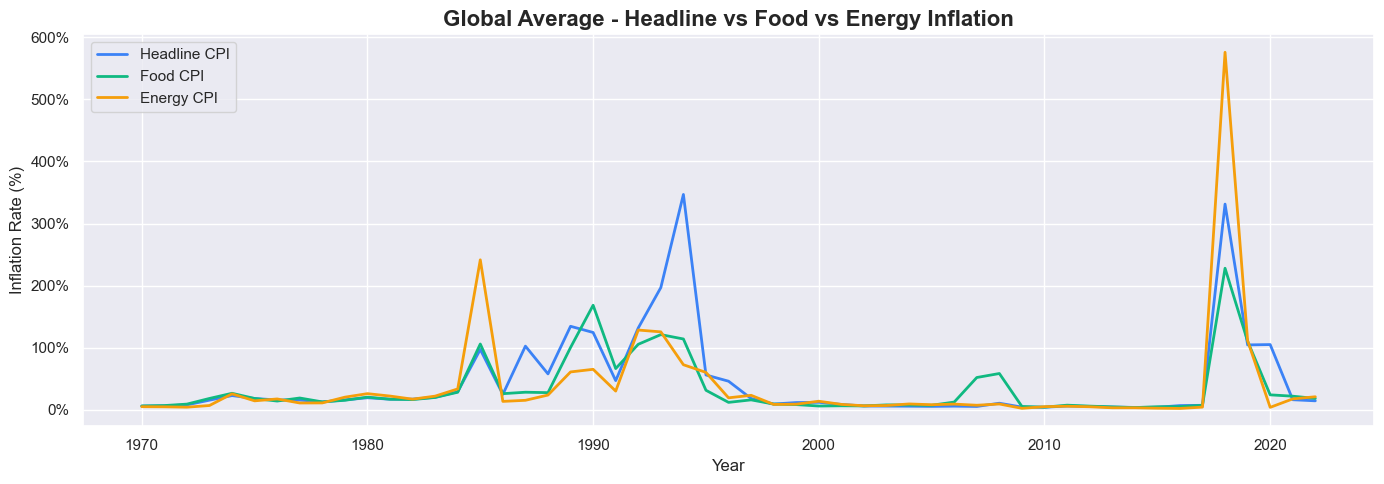

In [7]:
types  = ['Headline Consumer Price Inflation', 'Food Consumer Price Inflation', 'Energy Consumer Price Inflation']
labels = ['Headline CPI', 'Food CPI', 'Energy CPI']
colors = ['#3b82f6', '#10b981', '#f59e0b']

fig, ax = plt.subplots(figsize=(14, 5))
for itype, label, color in zip(types, labels, colors):
    subset = raw[raw['Series Name'] == itype][year_cols].apply(pd.to_numeric, errors='coerce')
    avg = subset.mean()
    avg = avg.dropna()
    ax.plot(avg.index.astype(int), avg.values, label=label, color=color, linewidth=2)

ax.set_title('Global Average - Headline vs Food vs Energy Inflation', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation Rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/inflation_types.png', dpi=150)
plt.show()

## 7. Inflation Heatmap - Selected Countries by Decade

In [ ]:
focus = ['United States', 'Germany', 'Argentina', 'Brazil', 'Japan',
         'China', 'United Kingdom', 'India', 'Russia', 'South Africa']

sel2 = headline[headline.index.get_level_values('Country').isin(focus)].copy()
sel2.index = sel2.index.get_level_values('Country')

# Decade averages
decades = {}
for start in range(1970, 2020, 10):
    cols = [str(y) for y in range(start, start+10) if str(y) in sel2.columns]
    decades[f'{start}s'] = sel2[cols].mean(axis=1)
decades['2020-22'] = sel2[[c for c in ['2020','2021','2022'] if c in sel2.columns]].mean(axis=1)

heat = pd.DataFrame(decades).clip(upper=100)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Avg Inflation by Decade - Selected Countries (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{OUT}/inflation_heatmap.png', dpi=150)
plt.show()

## 8. Key Statistics

In [9]:
all_vals = headline[year_cols].values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]

highest_country = headline[last_year].idxmax()[0]
highest_val     = headline[last_year].max()
lowest_country  = headline[last_year].idxmin()[0]
lowest_val      = headline[last_year].min()

print('=' * 50)
print('        ECONOSCOPE - KEY STATISTICS')
print('=' * 50)
print(f'  Countries Covered    : {len(headline)}')
print(f'  Years Covered        : {year_cols[0]} - {year_cols[-1]}')
print(f'  Global Avg Inflation : {np.mean(all_vals):.2f}%')
print(f'  All-time Max         : {np.max(all_vals):.1f}%')
print(f'  Highest in {last_year}   : {highest_country} ({highest_val:.1f}%)')
print(f'  Lowest in {last_year}    : {lowest_country} ({lowest_val:.1f}%)')
print('=' * 50)

        ECONOSCOPE - KEY STATISTICS
  Countries Covered    : 203
  Years Covered        : 1970 - 2022
  Global Avg Inflation : 44.11%
  All-time Max         : 65374.1%
  Highest in 2022   : Zimbabwe (284.9%)
  Lowest in 2022    : Macao SAR, China (1.1%)


---
**Tools:** Python - Pandas - NumPy - Matplotlib - Seaborn  
**Author:** Berke Arda Turk